## House Price Prediction using Machine Learning

## Objective:
The main objective of this project is to predict the price of a house based on different features, such as area, number of bedrooms, bathrooms, location-related information, parking, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\chand\Downloads\House Price Prediction Dataset1.csv")

# Drop unwanted column
df = df.drop(columns=['Id'], errors='ignore')

# Display first 5 rows
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1460,1,1,3,2014,Rural,Good,No,461297
1,4372,5,3,2,1975,Suburban,Poor,No,1184771
2,3692,5,3,2,1959,Urban,Good,No,1103954
3,1066,1,1,1,2019,Rural,Poor,No,305026
4,4044,4,4,3,1992,Rural,Good,No,1067784


In [3]:
df.shape

(5000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       5000 non-null   int64 
 1   Bedrooms   5000 non-null   int64 
 2   Bathrooms  5000 non-null   int64 
 3   Floors     5000 non-null   int64 
 4   YearBuilt  5000 non-null   int64 
 5   Location   5000 non-null   object
 6   Condition  5000 non-null   object
 7   Garage     5000 non-null   object
 8   Price      5000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 351.7+ KB


In [5]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [6]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,5000.000000,5000.00000,5000.0000,5000.000000,5000.00000,5.000000e+03
mean,2824.242200,2.96600,2.0202,1.873000,1986.49160,9.092347e+05
std,1255.980856,1.36851,0.9455,0.724828,21.24877,2.947722e+05
min,601.000000,1.00000,1.0000,1.000000,1950.00000,1.931530e+05
25%,1728.000000,2.00000,1.0000,1.000000,1968.00000,6.666490e+05
50%,2841.000000,3.00000,2.0000,2.000000,1987.00000,9.078695e+05
75%,3906.500000,4.00000,3.0000,2.000000,2005.00000,1.158592e+06
max,5000.000000,5.00000,4.0000,3.000000,2023.00000,1.637328e+06


In [7]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')


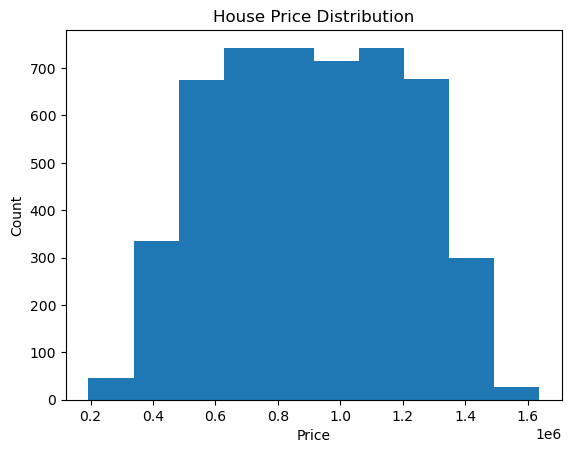

In [8]:
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("House Price Distribution")
plt.show()

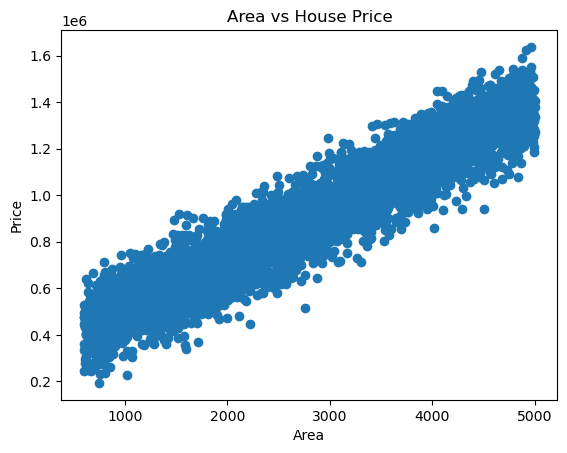

In [9]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs House Price")
plt.show()

## Correlation helps us understand relationships between numerical variables.
For example:

Area ↔ Price = positive correlation

This means larger houses generally have higher prices.

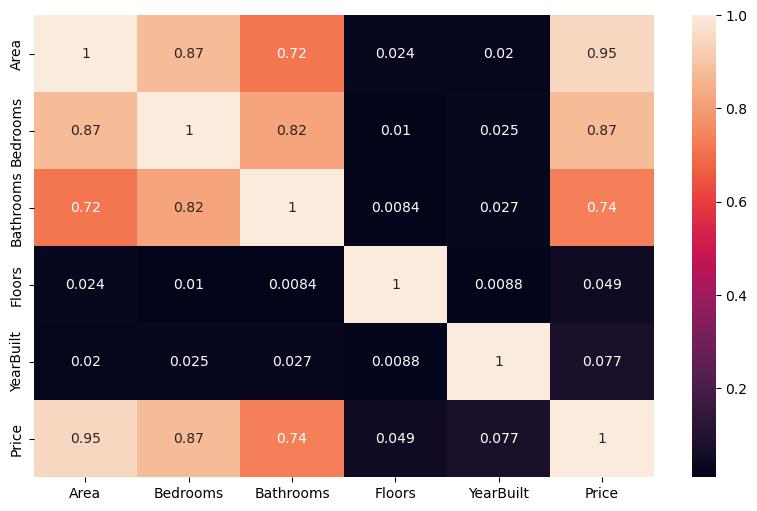

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## House Price Prediction project, I can convert the categorical columns Location, Condition, and Garage into numerical values using encoding.

In [11]:
# label_cols = ['Location', 'Condition', 'Garage'] 
# for col in label_cols: 
#     df[col] = LabelEncoder().fit_transform(df[col]) 

In [12]:
# df.head()

In [13]:
df['Location'].unique()

array(['Rural', 'Suburban', 'Urban', 'Downtown'], dtype=object)

In [14]:
df['Condition'].unique()

array(['Good', 'Poor', 'Excellent', 'Fair'], dtype=object)

In [15]:
df['Garage'].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
df = pd.get_dummies(
    df,
    columns=['Location', 'Condition', 'Garage'],
    dtype=int
)

In [17]:
scaler = StandardScaler()

df[['Area', 'YearBuilt']] = scaler.fit_transform(
    df[['Area', 'YearBuilt']]
)
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor,Garage_No,Garage_Yes
0,-1.086305,1,1,3,1.294717,461297,0,1,0,0,0,0,1,0,1,0
1,1.232433,5,3,2,-0.540867,1184771,0,0,1,0,0,0,0,1,1,0
2,0.690970,5,3,2,-1.293927,1103954,0,0,0,1,0,0,1,0,1,0
3,-1.400036,1,1,1,1.530049,305026,0,1,0,0,0,0,0,1,1,0
4,0.971257,4,4,3,0.259260,1067784,0,1,0,0,0,0,1,0,1,0


## The dataset itself may not contain enough predictive information for Linear Regression.

In [18]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price                  1.000000
Area                   0.947061
Bedrooms               0.873060
Bathrooms              0.735377
Location_Downtown      0.122707
Condition_Excellent    0.091905
YearBuilt              0.076528
Location_Urban         0.069375
Floors                 0.048755
Condition_Good         0.037538
Garage_Yes             0.036255
Garage_No             -0.036255
Condition_Fair        -0.058065
Location_Suburban     -0.066410
Condition_Poor        -0.101689
Location_Rural        -0.141560
Name: Price, dtype: float64

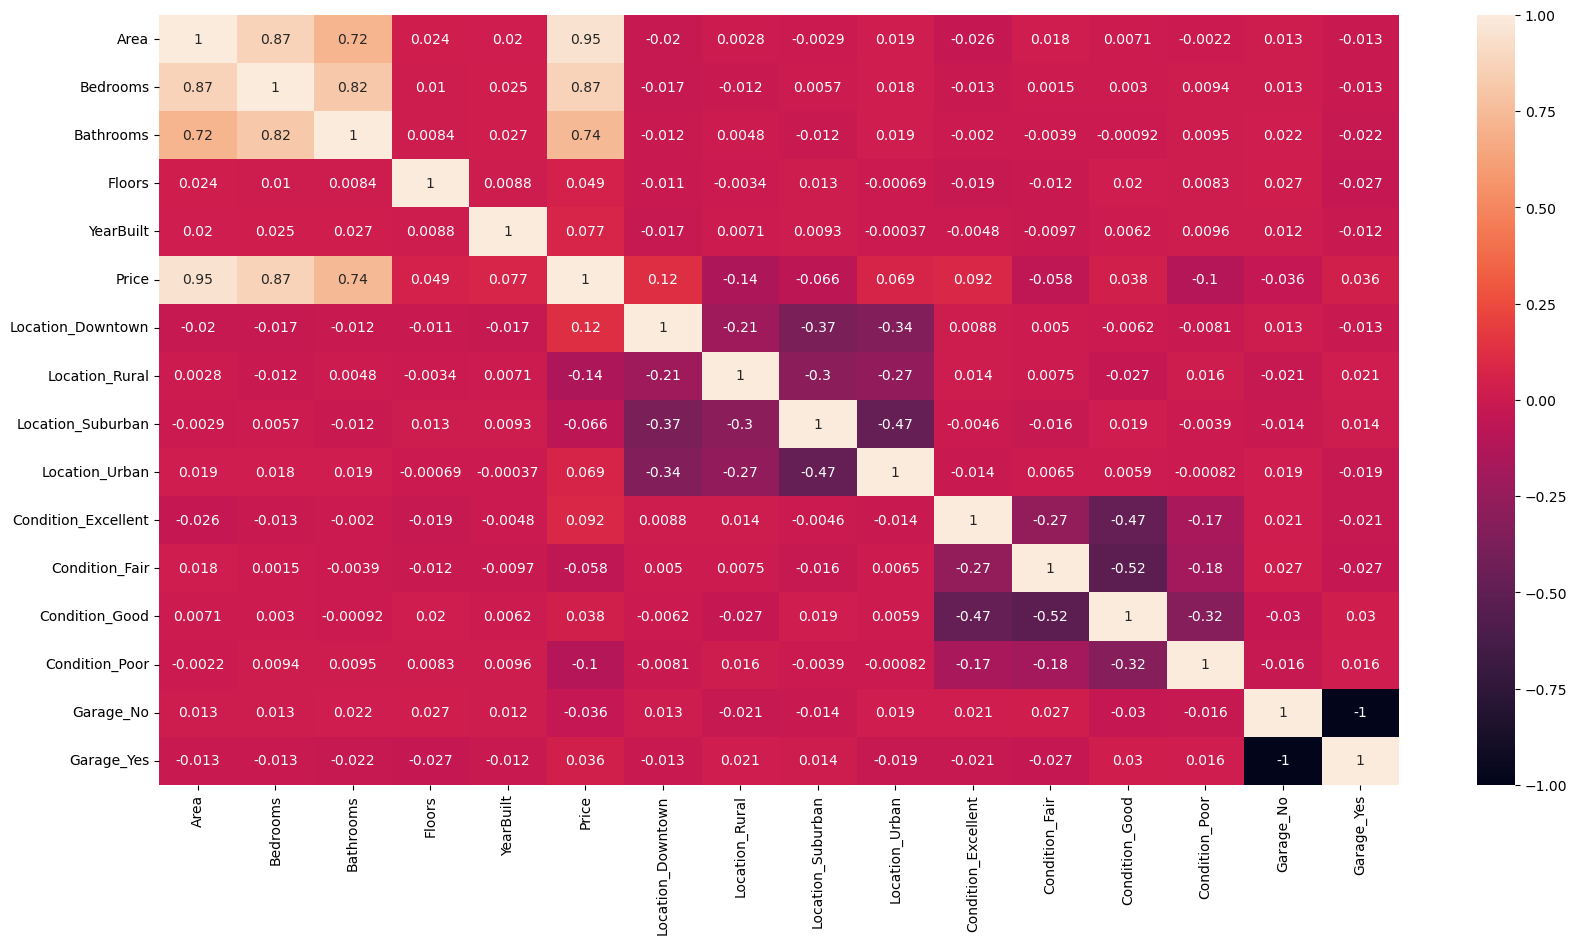

In [19]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Train-Test Split
## I separated the independent variables and dependent variable. X contains the input features used for prediction, while y contains the target variable, which is the house price.

We shouldn't train the model using 100% of the data.

We divide the dataset into:

Training data → used to train the model
Testing data → used to evaluate the model

## I divided the dataset into 80% training data and 20% testing data. The model learns patterns from the training data, and the testing data is used to check how well the model performs on unseen data.

In [20]:
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Selection
Since house price is a continuous numerical value, this is a Regression problem.

In [21]:
# from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## I trained the Linear Regression model using the training data. During training, the model learns how different house features influence the house price.

## Make Predictions

In [22]:
y_pred = reg.predict(X_test)
y_pred

array([1154028.69898285, 1164011.38729559,  886412.2980666 ,
       1396882.1294353 ,  468375.33187533,  822783.65098618,
        725058.80275513, 1000469.56805845,  622997.83405157,
       1205393.07522346, 1038371.48756386,  897798.05877051,
        578862.87482987,  892945.48511431,  437099.78556414,
       1413504.68326717, 1396347.88336715, 1375357.81959284,
       1003250.6902374 , 1437191.69596134, 1318514.02477518,
        490348.73991413,  884228.39742728,  751856.71265599,
       1386641.07879188, 1190739.0091463 ,  436948.18839079,
        711415.75922344, 1204731.25703391,  708766.30676443,
        889872.83323989,  429588.28728651,  958974.41256794,
        452581.56029829,  807697.30257456,  918272.94315171,
        824965.80140529,  634785.62480067,  510229.92439029,
        883463.34691889, 1181190.88872151,  514273.3521776 ,
       1185484.14394576,  494009.03706607,  545735.7748792 ,
        499664.61967512, 1128739.38244013,  803065.829001  ,
       1254077.82774377,

In [23]:
reg.score(X_test,y_test)

0.9759788862245561

## Evaluate the Model

We need to know how accurately our model predicts prices.

## R² Score

In [24]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9759788862245561


## R² = 1       → Excellent
## R² = 0       → Model is no better than simply predicting the average price
## R² < 0       → Model is performing worse than that simple baseline

## An R² score closer to 1 generally indicates that the model explains more of the variation in the target.

## MAE: MAE tells us the average absolute difference between actual and predicted prices.

In [25]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 36106.011834233206


## MSE: MSE gives more penalty to larger errors.

In [26]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2068474809.163412


## RMSE:-RMSE represents prediction error in the same units as the target.

In [27]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 45480.488224769666


## I evaluated the model using R², MAE, MSE and RMSE. R² tells me how well the model explains the target variation, while MAE and RMSE help me understand the prediction error.

## Compare Actual vs Predicted

In [28]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result.head())

       Actual     Predicted
1501  1224883  1.154029e+06
2586  1283219  1.164011e+06
2653   887037  8.864123e+05
1055  1369050  1.396882e+06
705    494923  4.683753e+05


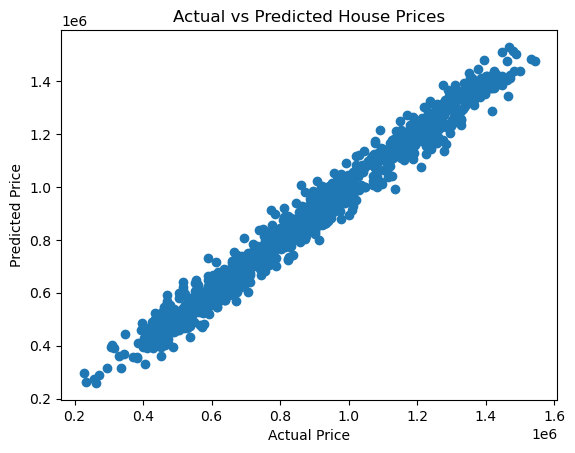

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Improve the Model

## Decision Tree Regressor

In [30]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
y_pred = model.predict(X_test)

In [32]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9267519562883206


In [33]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred = model.predict(X_test)

In [35]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9651115574936441


## I compared multiple regression algorithms and RandomForestRegressor model that provided the best performance based on evaluation metrics.

## Conclusion
## The House Price Prediction project successfully demonstrates the application of supervised machine learning for predicting house prices. The dataset contains 5,000 house records with numerical and categorical features such as Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, and Garage.

## During the project, data preprocessing, exploratory data analysis, correlation analysis, categorical encoding, feature preparation, and train-test splitting were performed. The analysis showed strong relationships between important features such as Area, Bedrooms, and Bathrooms and the target variable Price.

## A Linear Regression model was trained to predict house prices, and its performance was evaluated using R², MAE, MSE, and RMSE. The results demonstrate that the model can learn the relationship between house characteristics and their prices and can be used to estimate prices for previously unseen houses.

## Overall, the project shows how machine learning can be used to support data-driven house price estimation. Further improvements could include testing advanced regression algorithms such as Random Forest, Gradient Boosting, or XGBoost and performing hyperparameter tuning to potentially improve prediction performance.